In [1]:
# TencentMedicalNet/MedicalNet-Resnet50

In [2]:
# https://github.com/Project-MONAI/tutorials/discussions/516

In [3]:
# from setting import parse_opts 
# from datasets.brains18 import BrainS18Dataset
# from model import generate_model
import torch

from torch.utils.data import DataLoader
import torch.nn.functional as F
from scipy import ndimage
import nibabel as nib
import sys
import os
# from utils.file_process import load_lines



import numpy as np 
import pandas as pd
from torchsummaryX import summary
import nibabel                      as nib
import nibabel.freesurfer.mghformat as mgh
import matplotlib.pyplot as plt
from datetime import datetime
import sklearn.metrics

import glob
import re

import gc
from tqdm import tqdm


In [4]:
gc.collect()
torch.cuda.empty_cache()

In [5]:
import os
os.getcwd()

'/ocean/projects/cis230054p/ytam/Model'

In [6]:
# Optional: set project root manually
# os.chdir('<project_root>')
os.getcwd()

'/ocean/projects/cis230054p/ytam'

In [7]:
from MedicalNet.models import resnet_stack_cls

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)

Device:  cuda


In [9]:
W, H, D = 256, 256, 256

In [10]:
# getting model

model = resnet_stack_cls.resnet10(sample_input_W=W,
                sample_input_H=H,
                sample_input_D=D,
                shortcut_type='B',
                no_cuda = False,
                num_classes=2).to(device)

# https://stackoverflow.com/questions/54058256/runtimeerror-errors-in-loading-state-dict-for-resnet

/ocean/projects/cis230054p/ytam/MedicalNet/models/resnet_stack_cls.py:154: UserWarning: nn.init.kaiming_normal is now deprecated in favor of nn.init.kaiming_normal_.
  m.weight = nn.init.kaiming_normal(m.weight, mode='fan_out')


In [11]:
# first dim:  image
# second dim: segmentation

# Set seg_path

In [12]:
seg_path = r"./fastsurfer_stacked/fastsurfer_seg/{}_{}/mri/aparc.DKTatlas+aseg.deep.mgz"
# img_path = r"fastsurfer_seg_masked\masked_orig_nu_{}_{}.npy"
stacked_path = r"./fastsurfer_stacked/stacked_orig_seg_{}_{}.npy"

In [13]:
seg_path

'/ocean/projects/cis230054p/ytam/fastsurfer_stacked/fastsurfer_seg/{}_{}/mri/aparc.DKTatlas+aseg.deep.mgz'

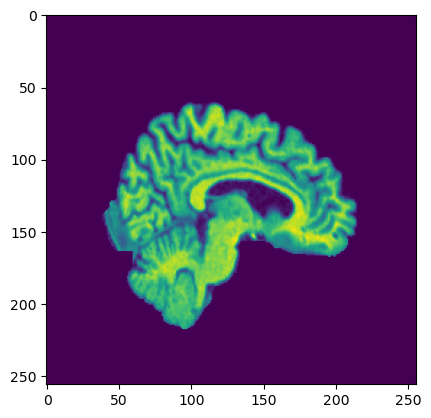

In [14]:
plt.imshow(np.load(r'./fastsurfer_stacked/stacked_orig_seg_sub-ADNI941S1203_ses-M00.npy')[0,120])

In [15]:
read_img = np.load(r'./fastsurfer_stacked/stacked_orig_seg_sub-ADNI941S1203_ses-M00.npy')[0]

In [16]:
read_img.shape

(256, 256, 256)

# Dataset

In [17]:
import os
import pandas as pd
from torch.utils.data import Dataset
import torch

class ADNI_stacked(Dataset):
    def __init__(self, csv_file, stacked_path, split = 'train', transform=None, target_transform=None):
        df = pd.read_csv(csv_file)
        
        if split == 'train':
            self.img_labels = df[df.split == 'train'] 
        elif split == 'val':
            self.img_labels = df[df.split == 'val'] 
        elif split == 'test':
            self.img_labels = df[df.split == 'test'] 
        self.stacked_path = stacked_path
        self.transform = transform
        self.target_transform = target_transform


    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        subject_id = self.img_labels.iloc[idx, 0]
        session_id = self.img_labels.iloc[idx, 1]
        final_path = self.stacked_path.format(subject_id, session_id)
        
        # np load
        stacked = np.load(final_path)

        label = self.img_labels.iloc[idx, 4]
        if self.transform:
            stacked = self.transform(stacked)
        if self.target_transform:
            label = self.target_transform(label)
        return stacked, label

In [18]:
# use seg_2 because of one (1) missing aseg_stat, reduce N to 2208
train_data = ADNI_stacked(r'ADNI_actual_used_seg_2.csv', stacked_path, split = 'train')
val_data = ADNI_stacked(r'ADNI_actual_used_seg_2.csv', stacked_path, split = 'val')
test_data = ADNI_stacked(r'ADNI_actual_used_seg_2.csv', stacked_path, split = 'test')

# DataLoader

In [19]:
from torch.utils.data import DataLoader
train_batch_size = 6 # smaller_batch
batch_size = 6

train_dataloader = DataLoader(train_data, batch_size=train_batch_size , shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size , shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=batch_size , shuffle=False)

Feature batch shape: torch.Size([2, 256, 256, 256])
Labels batch shape: 1


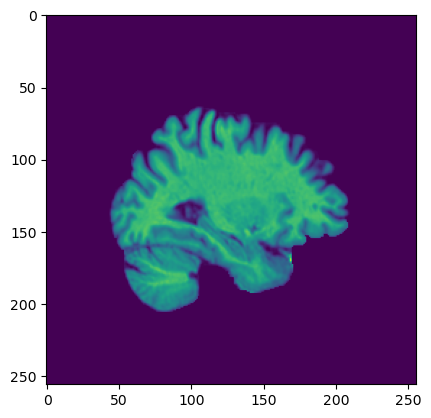

Label: 1


In [20]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features[0].size()}")
print(f"Labels batch shape: {train_labels[0]}")
img = train_features[0][0][100].squeeze()
label = train_labels[0]
plt.imshow(img)
plt.show()
print(f"Label: {label}")

In [21]:
loss_function = torch.nn.CrossEntropyLoss()
# loss_function = torch.nn.BCEWithLogitsLoss()  

optimizer = torch.optim.Adam(model.parameters(), 1e-4)

# Finetuned - epoch 70

In [19]:
# PATH = r'ResNet3d_multimodal_imgfrompretrain_segfromscratch_20231222_124640_f10.8558352402745995_epoch70.pth'
PATH = r'ResNet3d_multimodal_imgfrompretrain_segfromscratch_20231225_091626_f10.8843537414965986_epoch100.pth'

checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch_from_checkpoint = checkpoint['epoch']
loss = checkpoint['loss']


In [20]:
try:
    if PATH != None:
        epoch_start = epoch_from_checkpoint
except:
    epoch_start = 0


In [21]:
epoch_start

99

In [22]:
# test
test_outputs_lst = []
test_preds_lst = []
test_labels_lst = []


# eval
model.eval()

for test_data in tqdm(test_dataloader):
    test_inputs, test_labels = test_data[0].to(device), test_data[1].to(device)

    # inputs shape batchsize
    test_inputs = test_inputs.view(-1, 2, 256, 256, 256) # 2 because of stacked input
    with torch.no_grad():
        test_outputs = model(test_inputs.float())
        test_preds = torch.argmax(torch.nn.functional.softmax(test_outputs.detach()), dim=1)
        test_outputs_lst.extend(test_outputs.detach().cpu().numpy())
        test_preds_lst.extend(test_preds.detach().cpu().numpy())
        test_labels_lst.extend(test_labels.detach().cpu().numpy())

# metric = num_correct / metric_count
# metric_values.append(metric)

  0%|          | 0/65 [00:00<?, ?it/s]/tmp/ipykernel_100813/3944014520.py:17: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  test_preds = torch.argmax(torch.nn.functional.softmax(test_outputs.detach()), dim=1)
100%|██████████| 65/65 [13:07<00:00, 12.11s/it]


In [23]:
# sklearn 
import sklearn.metrics

sklearn.metrics.f1_score(test_labels_lst, test_preds_lst)

0.7920792079207922

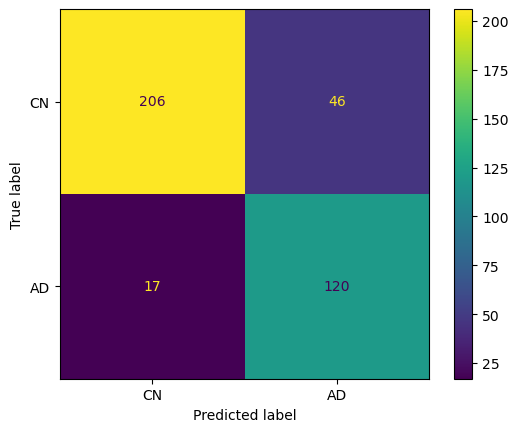

In [24]:
cm = sklearn.metrics.confusion_matrix(test_labels_lst, test_preds_lst)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [25]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(test_labels_lst, test_preds_lst))

              precision    recall  f1-score   support

           0       0.92      0.82      0.87       252
           1       0.72      0.88      0.79       137

    accuracy                           0.84       389
   macro avg       0.82      0.85      0.83       389
weighted avg       0.85      0.84      0.84       389



In [26]:
test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]

/tmp/ipykernel_100813/382836123.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]
/tmp/ipykernel_100813/382836123.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]


In [27]:
sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst)

0.8869916579770594

In [28]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(test_labels_lst, test_prob_preds_lst, pos_label=1)

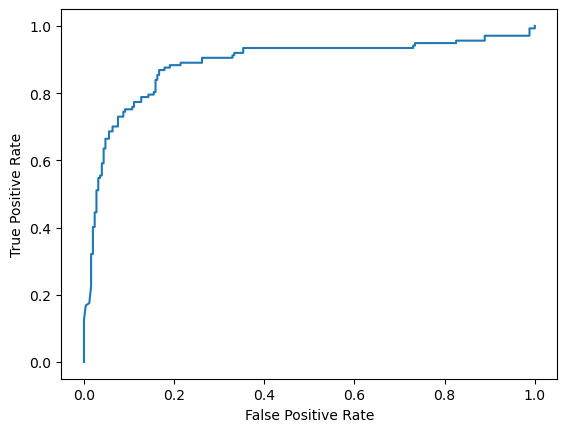

In [29]:
 sklearn.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

In [30]:
 sklearn.metrics.average_precision_score(test_labels_lst, test_prob_preds_lst, pos_label=1)

0.8410821684802009

In [31]:
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(test_labels_lst, test_prob_preds_lst, pos_label=1)

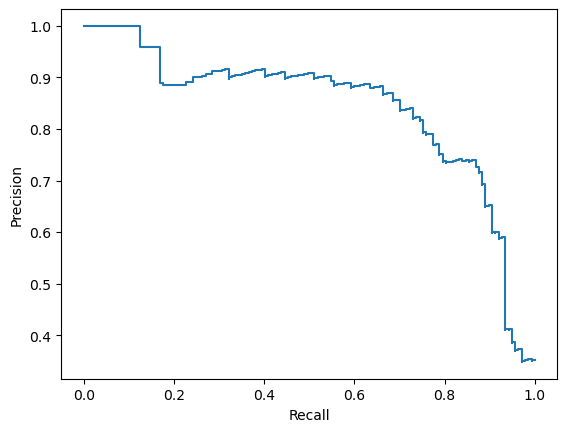

In [32]:
 sklearn.metrics.PrecisionRecallDisplay(precision, recall).plot()

In [33]:
print('F1:' + str(sklearn.metrics.f1_score(test_labels_lst, test_preds_lst, average = 'micro')))
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_labels_lst, test_preds_lst)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst)))
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_labels_lst, test_prob_preds_lst, pos_label=1)))

F1:0.8380462724935732
BA: 0.8466863631097208
AUROC: 0.8869916579770594
AUPRC: 0.8410821684802009


In [47]:
!nvcc --version

/usr/psc/shells/bash: nvcc: command not found


In [53]:
test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]

/tmp/ipykernel_82363/382836123.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]


In [54]:
sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst)

0.924110763526822

In [55]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(test_labels_lst, test_prob_preds_lst, pos_label=1)

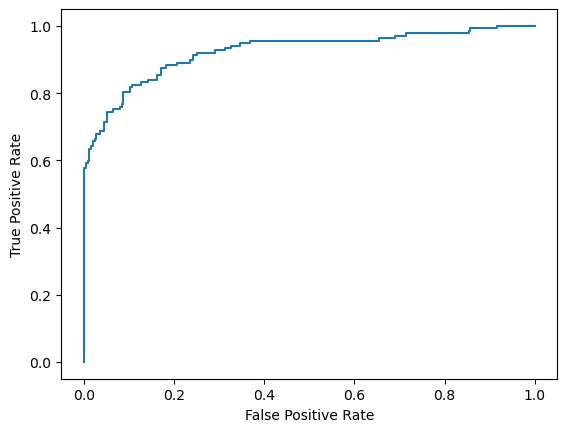

In [56]:
 sklearn.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

In [57]:
 sklearn.metrics.average_precision_score(test_labels_lst, test_prob_preds_lst, pos_label=1)

0.9082338018803109

In [58]:
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(test_labels_lst, test_prob_preds_lst, pos_label=1)

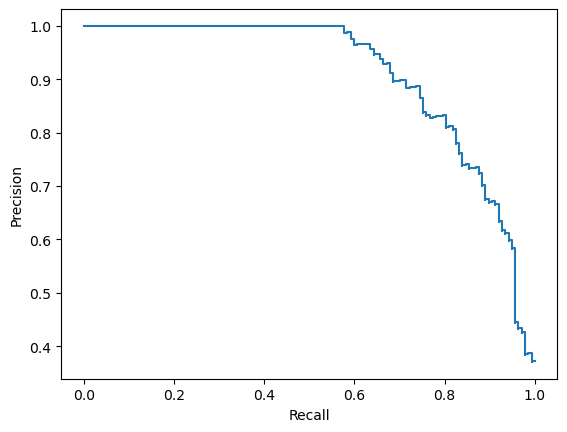

In [59]:
 sklearn.metrics.PrecisionRecallDisplay(precision, recall).plot()

In [60]:
print('F1:' + str(sklearn.metrics.f1_score(test_labels_lst, test_preds_lst, average = 'micro')))
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_labels_lst, test_preds_lst)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst)))
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_labels_lst, test_prob_preds_lst, pos_label=1)))

F1:0.8457583547557841
BA: 0.781021897810219
AUROC: 0.924110763526822
AUPRC: 0.9082338018803109


In [34]:
# PATH = r'ResNet3d_multimodal_imgfrompretrain_segfromscratch_20231222_124640_f10.8558352402745995_epoch70.pth'
PATH = r'ResNet3d_multimodal_imgfrompretrain_segfromscratch_20231220_134610_f10.9051094890510948_epoch46.pth'

checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch_from_checkpoint = checkpoint['epoch']
loss = checkpoint['loss']


In [35]:
epoch_from_checkpoint

45

# Finetuned - epoch 70

In [36]:
# test
test_outputs_lst = []
test_preds_lst = []
test_labels_lst = []


# eval
model.eval()

for test_data in tqdm(test_dataloader):
    test_inputs, test_labels = test_data[0].to(device), test_data[1].to(device)

    # inputs shape batchsize
    test_inputs = test_inputs.view(-1, 2, 256, 256, 256) # 2 because of stacked input
    with torch.no_grad():
        test_outputs = model(test_inputs.float())
        test_preds = torch.argmax(torch.nn.functional.softmax(test_outputs.detach()), dim=1)
        test_outputs_lst.extend(test_outputs.detach().cpu().numpy())
        test_preds_lst.extend(test_preds.detach().cpu().numpy())
        test_labels_lst.extend(test_labels.detach().cpu().numpy())

# metric = num_correct / metric_count
# metric_values.append(metric)

  0%|          | 0/65 [00:00<?, ?it/s]/tmp/ipykernel_100813/3944014520.py:17: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  test_preds = torch.argmax(torch.nn.functional.softmax(test_outputs.detach()), dim=1)
100%|██████████| 65/65 [05:03<00:00,  4.67s/it]


In [37]:
# sklearn 
import sklearn.metrics

sklearn.metrics.f1_score(test_labels_lst, test_preds_lst)

0.7640449438202246

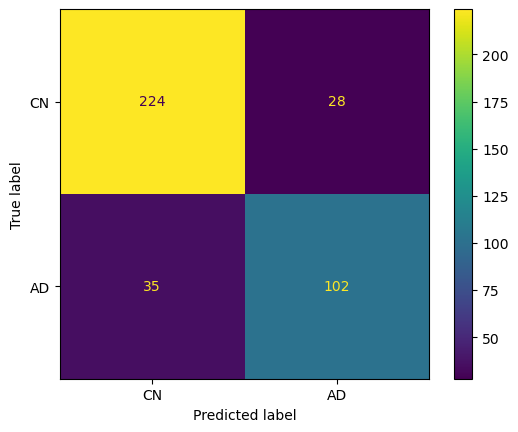

In [38]:
cm = sklearn.metrics.confusion_matrix(test_labels_lst, test_preds_lst)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [39]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(test_labels_lst, test_preds_lst))

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       252
           1       0.78      0.74      0.76       137

    accuracy                           0.84       389
   macro avg       0.82      0.82      0.82       389
weighted avg       0.84      0.84      0.84       389



In [40]:
test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]

/tmp/ipykernel_100813/382836123.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]


In [41]:
sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst)

0.8831827134746841

In [42]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(test_labels_lst, test_prob_preds_lst, pos_label=1)

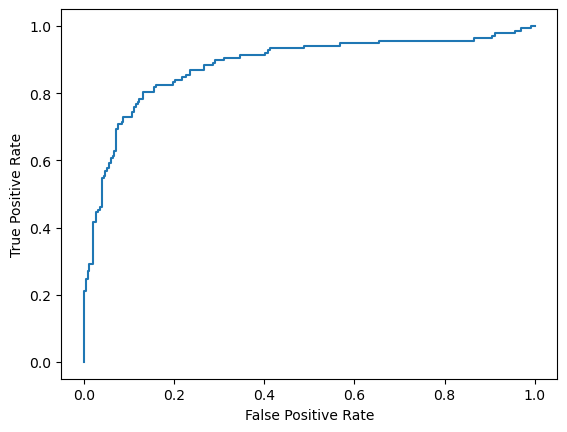

In [43]:
 sklearn.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

In [44]:
 sklearn.metrics.average_precision_score(test_labels_lst, test_prob_preds_lst, pos_label=1)

0.8382355925326451

In [45]:
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(test_labels_lst, test_prob_preds_lst, pos_label=1)

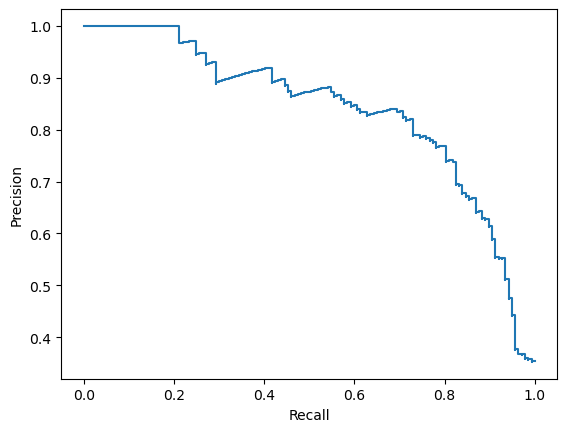

In [46]:
 sklearn.metrics.PrecisionRecallDisplay(precision, recall).plot()

In [47]:
print('F1:' + str(sklearn.metrics.f1_score(test_labels_lst, test_preds_lst, average = 'micro')))
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_labels_lst, test_preds_lst)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst)))
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_labels_lst, test_prob_preds_lst, pos_label=1)))

F1:0.8380462724935732
BA: 0.8167072181670721
AUROC: 0.8831827134746841
AUPRC: 0.8382355925326451


# Epoch 100

In [22]:
# PATH = r'ResNet3d_multimodal_imgfrompretrain_segfromscratch_20231222_124640_f10.8558352402745995_epoch70.pth'
PATH = r'ResNet3d_multimodal_imgfrompretrain_segfromscratch_20231225_091626_f10.8843537414965986_epoch100.pth'

checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch_from_checkpoint = checkpoint['epoch']
loss = checkpoint['loss']


In [23]:
epoch_from_checkpoint

99

In [24]:
# test
test_outputs_lst = []
test_preds_lst = []
test_labels_lst = []


# eval
model.eval()

for test_data in tqdm(test_dataloader):
    test_inputs, test_labels = test_data[0].to(device), test_data[1].to(device)

    # inputs shape batchsize
    test_inputs = test_inputs.view(-1, 2, 256, 256, 256) # 2 because of stacked input
    with torch.no_grad():
        test_outputs = model(test_inputs.float())
        test_preds = torch.argmax(torch.nn.functional.softmax(test_outputs.detach()), dim=1)
        test_outputs_lst.extend(test_outputs.detach().cpu().numpy())
        test_preds_lst.extend(test_preds.detach().cpu().numpy())
        test_labels_lst.extend(test_labels.detach().cpu().numpy())

# metric = num_correct / metric_count
# metric_values.append(metric)

  0%|          | 0/65 [00:00<?, ?it/s]/var/tmp/ipykernel_42224/3944014520.py:17: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  test_preds = torch.argmax(torch.nn.functional.softmax(test_outputs.detach()), dim=1)
100%|██████████| 65/65 [05:43<00:00,  5.29s/it]


In [25]:
# sklearn 
import sklearn.metrics

sklearn.metrics.f1_score(test_labels_lst, test_preds_lst)

0.7920792079207922

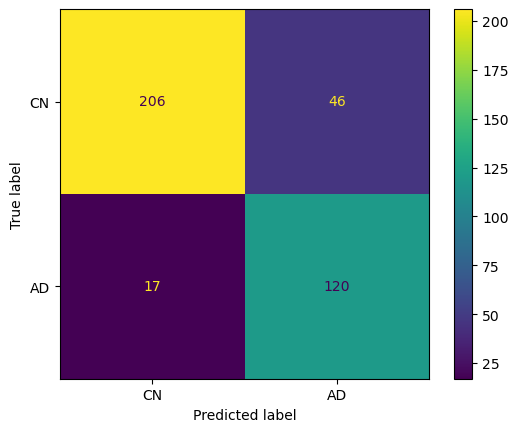

In [26]:
cm = sklearn.metrics.confusion_matrix(test_labels_lst, test_preds_lst)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [27]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(test_labels_lst, test_preds_lst))

              precision    recall  f1-score   support

           0       0.92      0.82      0.87       252
           1       0.72      0.88      0.79       137

    accuracy                           0.84       389
   macro avg       0.82      0.85      0.83       389
weighted avg       0.85      0.84      0.84       389



In [28]:
test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]

/var/tmp/ipykernel_42224/382836123.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]
/var/tmp/ipykernel_42224/382836123.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]


In [29]:
sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst)

0.8869916579770594

In [30]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(test_labels_lst, test_prob_preds_lst, pos_label=1)

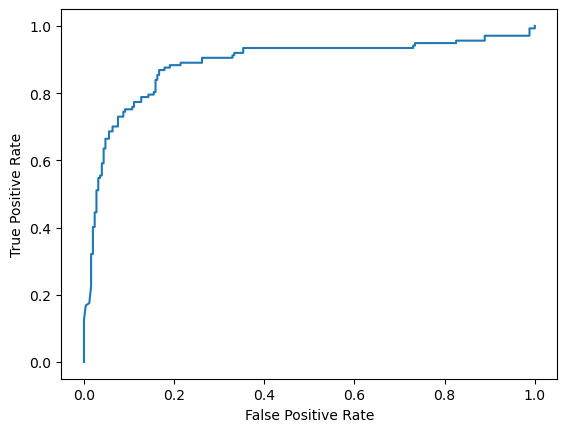

In [31]:
 sklearn.metrics.RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

In [32]:
 sklearn.metrics.average_precision_score(test_labels_lst, test_prob_preds_lst, pos_label=1)

0.8410821684802009

In [33]:
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(test_labels_lst, test_prob_preds_lst, pos_label=1)

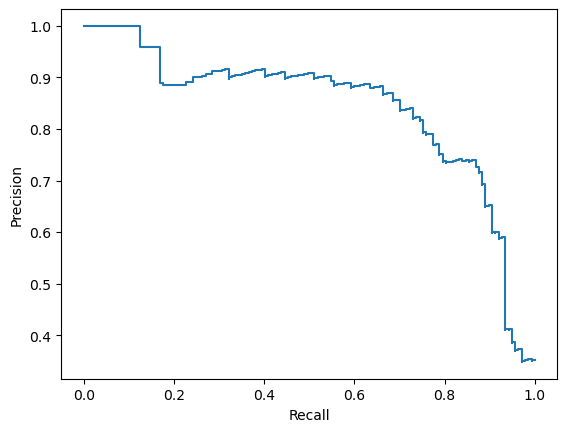

In [34]:
 sklearn.metrics.PrecisionRecallDisplay(precision, recall).plot()

In [35]:
print('F1:' + str(sklearn.metrics.f1_score(test_labels_lst, test_preds_lst, average = 'micro')))
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_labels_lst, test_preds_lst)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst))`)
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_labels_lst, test_prob_preds_lst, pos_label=1)))

F1:0.8380462724935732
BA: 0.8466863631097208
AUROC: 0.8869916579770594
AUPRC: 0.8410821684802009


In [39]:
ADNI_actual_used_seg_df = pd.read_csv(r'ADNI_actual_used_seg_2.csv')

In [36]:
pd.Series(test_preds_lst, name = 'bimodal_stack_mri_pretrain_pred')

0      1
1      1
2      1
3      0
4      0
      ..
384    0
385    0
386    0
387    0
388    0
Name: bimodal_stack_mri_pretrain_pred, Length: 389, dtype: int64

In [37]:
pd.Series(test_prob_preds_lst, name = 'bimodal_stack_mri_pretrain_prob_pred')

0      0.999998
1      1.000000
2      1.000000
3      0.000055
4      0.001563
         ...   
384    0.000174
385    0.000162
386    0.000221
387    0.009171
388    0.000063
Name: bimodal_stack_mri_pretrain_prob_pred, Length: 389, dtype: float32

In [40]:
test_result_df = pd.concat([ADNI_actual_used_seg_df[ADNI_actual_used_seg_df.split == 'test'].reset_index(), pd.Series(test_preds_lst, name = 'bimodal_stack_mri_pretrain_pred'),pd.Series(test_prob_preds_lst, name = 'bimodal_stack_mri_pretrain_prob_pred')],  axis = 1)

In [41]:
test_result_df

,index,participant_id,session_id,age,sex,diagnosis,split,bimodal_stack_mri_pretrain_pred,bimodal_stack_mri_pretrain_prob_pred
0,95,sub-ADNI126S0891,ses-M06,79.3,Female,1,test,1,0.999998
1,96,sub-ADNI126S0891,ses-M12,79.3,Female,1,test,1,1.000000
2,97,sub-ADNI126S0891,ses-M24,79.3,Female,1,test,1,1.000000
3,108,sub-ADNI114S0416,ses-M00,75.6,Female,0,test,0,0.000055
4,109,sub-ADNI114S0416,ses-M06,75.6,Female,0,test,0,0.001563
...,...,...,...,...,...,...,...,...,...
384,2186,sub-ADNI023S0058,ses-M24,70.1,Male,0,test,0,0.000174
385,2187,sub-ADNI023S0058,ses-M48,70.1,Male,0,test,0,0.000162
386,2188,sub-ADNI023S0058,ses-M60,70.1,Male,0,test,0,0.000221
387,2189,sub-ADNI023S0058,ses-M72,70.1,Male,0,test,0,0.009171


In [42]:
test_result_df.to_csv('test_result_df_bimodal_stack_mri_pretrain_pred_epoch_100.csv')